# Задача 1
Сначала про первую задачку - EEG считывает электрические сигналы мозга и позволяет понять, насколько активен мозг в данный момент. Приступ эпилепсии характеризуется аномальной активностью мозга, которую можно попытаться задетектировать при помощи EEG, что мы и будем делать в рамках первой задачи.

- Скачайте данные из репозитория - https://huggingface.co/datasets/ankislyakov/EpilepticSeizureRecognition/resolve/main/Epileptic%20Seizure%20Recognition.csv
- Проведите EDA, а также трансформируйте целевую переменную из многоклассовой в бинарную - класс 1 (приступ) против всех остальных и отложите 20% данных для тестирования (не забудьте про стратификацию).
- Постройте бейзлайн, используя сырые данные в качестве признаков, без дополнительной предобработки. В качестве модели (или даже моделей) можете выбрать любой полюбившийся вам алгоритм.
- Так как каждый временной ряд представляет собой сигнал из 178 наблюдений, пришедших за 1 секунду, имеет смысл попробовать методы извлечения признаков из сигналов. Извлеките FFT и Wavelet признаки и снова обучите модель/модели и проверьте качество.
- Наконец, при помощи библиотеки для автоматического извлечения признаков из временных рядов сгенерируйте статистические признаки и снова проверьте качество моделей.
- Какой из подходов показал лучшее качество?

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


In [2]:
df = pd.read_csv('https://huggingface.co/datasets/ankislyakov/EpilepticSeizureRecognition/resolve/main/Epileptic%20Seizure%20Recognition.csv')

In [3]:
df

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11495,X22.V1.114,-22,-22,-23,-26,-36,-42,-45,-42,-45,...,15,16,12,5,-1,-18,-37,-47,-48,2
11496,X19.V1.354,-47,-11,28,77,141,211,246,240,193,...,-65,-33,-7,14,27,48,77,117,170,1
11497,X8.V1.28,14,6,-13,-16,10,26,27,-9,4,...,-65,-48,-61,-62,-67,-30,-2,-1,-8,5
11498,X10.V1.932,-40,-25,-9,-12,-2,12,7,19,22,...,121,135,148,143,116,86,68,59,55,3


<Axes: >

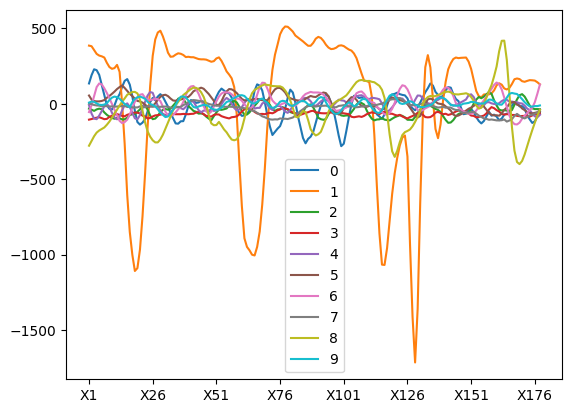

In [4]:
df.iloc[0:10, 1:179].T.plot()

In [5]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.00000,11500.00000,11500.000000,...,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000
mean,-11.581391,-10.911565,-10.187130,-9.143043,-8.009739,-7.003478,-6.502087,-6.68713,-6.55800,-6.168435,...,-10.145739,-11.630348,-12.943478,-13.668870,-13.363304,-13.045043,-12.705130,-12.426000,-12.195652,3.000000
std,165.626284,166.059609,163.524317,161.269041,160.998007,161.328725,161.467837,162.11912,162.03336,160.436352,...,164.652883,166.149790,168.554058,168.556486,167.257290,164.241019,162.895832,162.886311,164.852015,1.414275
min,-1839.000000,-1838.000000,-1835.000000,-1845.000000,-1791.000000,-1757.000000,-1832.000000,-1778.00000,-1840.00000,-1867.000000,...,-1867.000000,-1865.000000,-1642.000000,-1723.000000,-1866.000000,-1863.000000,-1781.000000,-1727.000000,-1829.000000,1.000000
25%,-54.000000,-55.000000,-54.000000,-54.000000,-54.000000,-54.000000,-54.000000,-55.00000,-55.00000,-54.000000,...,-55.000000,-56.000000,-56.000000,-56.000000,-55.000000,-56.000000,-55.000000,-55.000000,-55.000000,2.000000
50%,-8.000000,-8.000000,-7.000000,-8.000000,-8.000000,-8.000000,-8.000000,-8.00000,-7.00000,-7.000000,...,-9.000000,-10.000000,-10.000000,-10.000000,-10.000000,-9.000000,-9.000000,-9.000000,-9.000000,3.000000
75%,34.000000,35.000000,36.000000,36.000000,35.000000,36.000000,35.000000,36.00000,36.00000,35.250000,...,34.000000,34.000000,33.000000,33.000000,34.000000,34.000000,34.000000,34.000000,34.000000,4.000000
max,1726.000000,1713.000000,1697.000000,1612.000000,1518.000000,1816.000000,2047.000000,2047.00000,2047.00000,2047.000000,...,1777.000000,1472.000000,1319.000000,1436.000000,1733.000000,1958.000000,2047.000000,2047.000000,1915.000000,5.000000


In [6]:
df['y'].value_counts()

y
4    2300
1    2300
5    2300
2    2300
3    2300
Name: count, dtype: int64

In [7]:
df['target'] = df['y'].apply(lambda x: 1 if x == 1 else 0)

/var/folders/yv/y6gd0q0d7k14thdfy7xxxs140000gn/T/ipykernel_81841/73270037.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['target'] = df['y'].apply(lambda x: 1 if x == 1 else 0)


In [8]:
X = df.drop(columns=["y", "target", "Unnamed"])
y = df["target"]

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [11]:
def evaluate_model(clf, X_train, y_train, X_test, y_test, name="model"):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # ROC-AUC по вероятностям / скору
    if hasattr(clf, "predict_proba"):
        y_proba = clf.predict_proba(X_test)[:, 1]
    elif hasattr(clf, "decision_function"):
        y_proba = clf.decision_function(X_test)
    else:
        y_proba = None

    # classification_report в виде словаря
    report_dict = classification_report(
        y_test,
        y_pred,
        digits=4,
        output_dict=True
    )

    # Печать красивого отчёта
    print(f"=== {name} ===")
    print("Classification report (0=non-seizure, 1=seizure):")
    print(classification_report(y_test, y_pred, digits=4))

    # ROC-AUC
    if y_proba is not None:
        auc = roc_auc_score(y_test, y_proba)
        print(f"ROC-AUC: {auc:.4f}")
    else:
        auc = None
        print("ROC-AUC: N/A (no scores available)")

    print()

    # Извлекаем нужные числа для итоговой таблицы
    accuracy = report_dict["accuracy"]
    f1_1 = report_dict["1"]["f1-score"]
    precision_1 = report_dict["1"]["precision"]
    recall_1 = report_dict["1"]["recall"]

    return {
        "name": name,
        "roc_auc": auc,
        "accuracy": accuracy,
        "f1_1": f1_1,
        "precision_1": precision_1,
        "recall_1": recall_1,
    }

In [12]:
logreg_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=42,
    )),
])

res_logreg = evaluate_model(logreg_clf, X_train, y_train, X_test, y_test, name="Logistic Regression")

=== Logistic Regression ===
Classification report (0=non-seizure, 1=seizure):
              precision    recall  f1-score   support

           0     0.8133    0.9989    0.8966      1840
           1     0.9500    0.0826    0.1520       460

    accuracy                         0.8157      2300
   macro avg     0.8816    0.5408    0.5243      2300
weighted avg     0.8406    0.8157    0.7477      2300

ROC-AUC: 0.4996



In [13]:
svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,   # чтобы был predict_proba для ROC-AUC
        random_state=42,
    )),
])

res_svm = evaluate_model(svm_clf, X_train, y_train, X_test, y_test, name="SVM RBF")

=== SVM RBF ===
Classification report (0=non-seizure, 1=seizure):
              precision    recall  f1-score   support

           0     0.9748    0.9891    0.9819      1840
           1     0.9538    0.8978    0.9250       460

    accuracy                         0.9709      2300
   macro avg     0.9643    0.9435    0.9534      2300
weighted avg     0.9706    0.9709    0.9705      2300

ROC-AUC: 0.9965



In [14]:
cat_clf = CatBoostClassifier(
    depth=6,
    learning_rate=0.1,
    n_estimators=300,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False,
)

res_cat = evaluate_model(cat_clf, X_train, y_train, X_test, y_test, name="CatBoost")

=== CatBoost ===
Classification report (0=non-seizure, 1=seizure):
              precision    recall  f1-score   support

           0     0.9791    0.9918    0.9854      1840
           1     0.9656    0.9152    0.9397       460

    accuracy                         0.9765      2300
   macro avg     0.9723    0.9535    0.9626      2300
weighted avg     0.9764    0.9765    0.9763      2300

ROC-AUC: 0.9965



In [15]:
results = pd.DataFrame([res_logreg, res_svm, res_cat])
print(results)

                  name   roc_auc  accuracy      f1_1  precision_1  recall_1
0  Logistic Regression  0.499627  0.815652  0.152000     0.950000  0.082609
1              SVM RBF  0.996471  0.970870  0.924972     0.953811  0.897826
2             CatBoost  0.996495  0.976522  0.939732     0.965596  0.915217


In [17]:
X

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178
0,135,190,229,223,192,125,55,-9,-33,-38,...,8,-17,-15,-31,-77,-103,-127,-116,-83,-51
1,386,382,356,331,320,315,307,272,244,232,...,168,164,150,146,152,157,156,154,143,129
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,29,57,64,48,19,-12,-30,-35,-35,-36
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-80,-82,-81,-80,-77,-85,-77,-72,-69,-65
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,10,4,2,-12,-32,-41,-65,-83,-89,-73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11495,-22,-22,-23,-26,-36,-42,-45,-42,-45,-49,...,20,15,16,12,5,-1,-18,-37,-47,-48
11496,-47,-11,28,77,141,211,246,240,193,136,...,-94,-65,-33,-7,14,27,48,77,117,170
11497,14,6,-13,-16,10,26,27,-9,4,14,...,-42,-65,-48,-61,-62,-67,-30,-2,-1,-8
11498,-40,-25,-9,-12,-2,12,7,19,22,29,...,114,121,135,148,143,116,86,68,59,55


In [19]:
tmp = X.iloc[0,:]

In [27]:
def generate_fft_features(signal):
    fft_values = np.fft.fft(signal)
    power_spectrum = np.abs(fft_values) ** 2
    return power_spectrum[:len(power_spectrum) // 2]  #Возвращаем только первые N/2 значений

In [34]:
fft_features_train = [generate_fft_features(row) for _, row in X_train.iterrows()]
X_fft_train = pd.DataFrame(fft_features_train, index=X_train.index)

fft_features_test = [generate_fft_features(row) for _, row in X_test.iterrows()]
X_fft_test = pd.DataFrame(fft_features_test, index=X_test.index)

In [35]:
res_fft_logreg = evaluate_model(logreg_clf, X_fft_train, y_train, X_fft_test, y_test, name="Logistic Regression FFT")
res_fft_svm = evaluate_model(svm_clf, X_fft_train, y_train, X_fft_test, y_test, name="SVM RBF FFT")
res_fft_cat = evaluate_model(cat_clf, X_fft_train, y_train, X_fft_test, y_test, name="CatBoost FFT")
results_fft = pd.DataFrame([res_fft_logreg, res_fft_svm, res_fft_cat])
print(results_fft)

=== Logistic Regression FFT ===
Classification report (0=non-seizure, 1=seizure):
              precision    recall  f1-score   support

           0     0.9723    0.9935    0.9828      1840
           1     0.9714    0.8870    0.9273       460

    accuracy                         0.9722      2300
   macro avg     0.9719    0.9402    0.9550      2300
weighted avg     0.9722    0.9722    0.9717      2300

ROC-AUC: 0.9870

=== SVM RBF FFT ===
Classification report (0=non-seizure, 1=seizure):
              precision    recall  f1-score   support

           0     0.9656    0.9918    0.9786      1840
           1     0.9634    0.8587    0.9080       460

    accuracy                         0.9652      2300
   macro avg     0.9645    0.9253    0.9433      2300
weighted avg     0.9652    0.9652    0.9645      2300

ROC-AUC: 0.9966

=== CatBoost FFT ===
Classification report (0=non-seizure, 1=seizure):
              precision    recall  f1-score   support

           0     0.9913    0.9902 

In [ ]:
import numpy as np
import pywt

# фиксируем параметры
WAVELET = "morl"      # популярный волнопакет для CWT
N_SCALES = 32         # сколько масштабов (фич) хотим
SAMPLE_RATE = 178.0   # частота дискретизации (178 точек за секунду)

def extract_cwt_features_from_row(row, n_scales=N_SCALES, sample_rate=SAMPLE_RATE):

    # превращаем строку в 1D сигнал
    y = row.to_numpy(dtype=float)

    # Scales для CWT
    scales = np.arange(1, n_scales + 1)

    # Непрерывное вейвлет-преобразование
    # coefficients.shape -> (n_scales, len(y))
    coefficients, frequencies = pywt.cwt(
        y,
        scales,
        WAVELET,
        sampling_period=1.0 / sample_rate
    )

    # Модуль коэффициентов (амплитуда)
    scalogram = np.abs(coefficients)

    # Усредняем по времени: получаем вектор длины n_scales
    features = np.mean(scalogram, axis=1)

    return features  # np.array (n_scales,)

In [46]:
cwt_features_train = [
    extract_cwt_features_from_row(row)
    for _, row in X_train.iterrows()
]
X_cwt_train = pd.DataFrame(
    cwt_features_train,
    index=X_train.index,
    columns=[f"cwt_scale_{i+1}" for i in range(N_SCALES)]
)

cwt_features_test = [
    extract_cwt_features_from_row(row)
    for _, row in X_test.iterrows()
]
X_cwt_test = pd.DataFrame(
    cwt_features_test,
    index=X_test.index,
    columns=[f"cwt_scale_{i+1}" for i in range(N_SCALES)]
)

In [47]:
res_cwt_logreg = evaluate_model(logreg_clf, X_cwt_train, y_train, X_cwt_test, y_test, name="Logistic Regression CWT")
res_cwt_svm = evaluate_model(svm_clf, X_cwt_train, y_train, X_cwt_test, y_test, name="SVM RBF CWT")
res_cwt_cat = evaluate_model(cat_clf, X_cwt_train, y_train, X_cwt_test, y_test, name="CatBoost CWT")
results_cwt = pd.DataFrame([res_cwt_logreg, res_cwt_svm, res_cwt_cat])
print(results_cwt)

=== Logistic Regression CWT ===
Classification report (0=non-seizure, 1=seizure):
              precision    recall  f1-score   support

           0     0.9791    0.9924    0.9857      1840
           1     0.9678    0.9152    0.9408       460

    accuracy                         0.9770      2300
   macro avg     0.9735    0.9538    0.9632      2300
weighted avg     0.9768    0.9770    0.9767      2300

ROC-AUC: 0.9947

=== SVM RBF CWT ===
Classification report (0=non-seizure, 1=seizure):
              precision    recall  f1-score   support

           0     0.9833    0.9935    0.9884      1840
           1     0.9728    0.9326    0.9523       460

    accuracy                         0.9813      2300
   macro avg     0.9781    0.9630    0.9703      2300
weighted avg     0.9812    0.9813    0.9812      2300

ROC-AUC: 0.9966

=== CatBoost CWT ===
Classification report (0=non-seizure, 1=seizure):
              precision    recall  f1-score   support

           0     0.9929    0.9946 

In [48]:
import tsfel

cfg = tsfel.get_features_by_domain()

/Users/vadim/Code/OTUS/ML-Advanced/.venv/lib/python3.12/site-packages/tsfel/feature_extraction/calc_features.py:195: SyntaxWarning: invalid escape sequence '\*'
  \**kwargs:


In [60]:
import pandas as pd
import tsfel

def tsfel_extract_features_from_matrix(X, cfg=None, fs=178.0, verbose=0):


    feature_rows = []

    # Идём по строкам: каждая строка - отдельный сигнал
    for idx, row in tqdm(X.iterrows(), total=X.shape[0]):
        signal = pd.Series(row.to_numpy(), name="signal")

        feats = tsfel.time_series_features_extractor(
            cfg,
            signal,
            fs=fs,
            verbose=verbose
        )

        # feats - DataFrame с одной строкой фич
        feature_rows.append(feats.iloc[0])

    # Собираем все строки в один DataFrame, индекс сохраняем из X
    X_tsfel = pd.DataFrame(feature_rows, index=X.index)

    return X_tsfel

In [61]:
X_tsfel_train = tsfel_extract_features_from_matrix(X_train, cfg=cfg)
X_tsfel_test  = tsfel_extract_features_from_matrix(X_test,  cfg=cfg)

100%|██████████| 2300/2300 [00:11<00:00, 197.74it/s]


In [63]:
res_tsfel_logreg = evaluate_model(logreg_clf, X_tsfel_train, y_train, X_tsfel_test, y_test, name="Logistic Regression TSFEL")
res_tsfel_svm = evaluate_model(svm_clf, X_tsfel_train, y_train, X_tsfel_test, y_test, name="SVM RBF TSFEL")
res_tsfel_cat = evaluate_model(cat_clf, X_tsfel_train, y_train, X_tsfel_test, y_test, name="CatBoost TSFEL")
results_tsfel = pd.DataFrame([res_tsfel_logreg, res_tsfel_svm, res_tsfel_cat])
print(results_tsfel)

=== Logistic Regression TSFEL ===
Classification report (0=non-seizure, 1=seizure):
              precision    recall  f1-score   support

           0     0.9924    0.9951    0.9938      1840
           1     0.9802    0.9696    0.9749       460

    accuracy                         0.9900      2300
   macro avg     0.9863    0.9823    0.9843      2300
weighted avg     0.9900    0.9900    0.9900      2300

ROC-AUC: 0.9948

=== SVM RBF TSFEL ===
Classification report (0=non-seizure, 1=seizure):
              precision    recall  f1-score   support

           0     0.9946    0.9957    0.9951      1840
           1     0.9825    0.9783    0.9804       460

    accuracy                         0.9922      2300
   macro avg     0.9886    0.9870    0.9878      2300
weighted avg     0.9922    0.9922    0.9922      2300

ROC-AUC: 0.9993

=== CatBoost TSFEL ===
Classification report (0=non-seizure, 1=seizure):
              precision    recall  f1-score   support

           0     0.9967    0

In [64]:
result_all = pd.concat([results, results_fft, results_cwt, results_tsfel], ignore_index=True)

In [65]:
result_all

,name,roc_auc,accuracy,f1_1,precision_1,recall_1
0,Logistic Regression,0.499627,0.815652,0.152000,0.950000,0.082609
1,SVM RBF,0.996471,0.970870,0.924972,0.953811,0.897826
2,CatBoost,0.996495,0.976522,0.939732,0.965596,0.915217
3,Logistic Regression FFT,0.987011,0.972174,0.927273,0.971429,0.886957
4,SVM RBF FFT,0.996556,0.965217,0.908046,0.963415,0.858696
5,CatBoost FFT,0.998801,0.985217,0.963124,0.961039,0.965217
6,Logistic Regression CWT,0.994682,0.976957,0.940782,0.967816,0.915217
7,SVM RBF CWT,0.996583,0.981304,0.952275,0.972789,0.932609
8,CatBoost CWT,0.998142,0.990000,0.974918,0.978118,0.971739
9,Logistic Regression TSFEL,0.994838,0.990000,0.974863,0.980220,0.969565


Будем считать Recall по классу 1 главней метрикой модели

In [70]:
def split_name(name):
    parts = name.split()
    if parts[-1] in ["FFT", "CWT", "TSFEL"]:
        feat = parts[-1]
        model = " ".join(parts[:-1])
    else:
        feat = "0Raw"
        model = " ".join(parts)
    return model, feat

result_all[["model", "features"]] = result_all["name"].apply(
    lambda s: pd.Series(split_name(s))
)

pivot_recall_1 = result_all.pivot_table(
    index="model",
    columns="features",
    values="recall_1"
)


In [ ]:
pivot_recall_1

features,0Raw,CWT,FFT,TSFEL
model,,,,
CatBoost,0.915217,0.971739,0.965217,0.986957
Logistic Regression,0.082609,0.915217,0.886957,0.969565
SVM RBF,0.897826,0.932609,0.858696,0.978261


TSFel дал прирост по всем моделям. 

Особенно это хорошо видно на логистической регрессии, которая не справилась с сырыми данными

# Задача 2

А теперь задачка под номером два - анализ финансовых рядов. Как вы наверняка знаете, самой популярной криптовалютой является Bitcoin, стоимость которого уже превысила $15k. Однако, в мире существуют еще несколько тысяч альтернативных криптовалют, бОльшая часть из которых ничего особенного из себя не представляют и даже динамика их цен совпадает с флагманским биткоином. Вашей задачей будет найти криптовалюты, которые не будут попадать в кластер биткоина на разных временных промежутках

- Установите библиотеку cryptocompare (https://pypi.org/project/cryptocompare/)
- Используя cryptocompare.get_coin_list(format=True) получите список из всех торгующихся криптовалют (должно получиться больше 5600). Если желания долго скачивать данные нет, то можно случайным образом отобрать штучек 100 валют из этого списка, только убедитесь, что биткоин (символ - BTC) в него всё ещё входит.
- Теперь скачайте цены закрытия для имеющихся криптовалют по трем разным временным промежуткам:
- За последние 30 дней с дневной частотой - cryptocompare.get_historical_price_day(ticker, curr='USD', limit=30)
- За последние 3 дня с часовой частотой - cryptocompare.get_historical_price_hour(ticker, curr='USD', limit=3*24)
- За последний час с минутной частотой - cryptocompare.get_historical_price_minute(ticker, curr='USD', limit=60)
- А теперь самое интересное - проведите кластерный анализ для каждой из временных групп и найдите валюты, которые попали в кластеры, отличные от кластера с биткоином, попробуйте как “классическую” кластеризацию, так и DTW.


In [155]:
import cryptocompare
import time


In [157]:
coins_raw = cryptocompare.get_pairs(exchange='Kraken')
tickers = [pair['fsym'] for pair in coins_raw if pair['tsym'] == "USD"]

In [158]:
def load_ohlc_list(func, ticker, limit):
    try:
        data = func(ticker, limit=limit, currency="USD", exchange="Kraken")
        if not data:
            return []
        closes = [d["close"] for d in data if isinstance(d, dict) and d.get("close") is not None]
        return closes
    except Exception:
        return []

In [154]:
cryptocompare.get_historical_price_day("CRO", currency="USD", limit=30, exchange="Kraken")

[{'time': 1771891200,
  'close': 0.07419,
  'high': 0.07523,
  'low': 0.07341,
  'open': 0.07411,
  'volumefrom': 963447.52,
  'volumeto': 71478.5,
  'conversionType': 'force_direct',
  'conversionSymbol': ''},
 {'time': 1771977600,
  'close': 0.07817,
  'high': 0.08046,
  'low': 0.07407,
  'open': 0.07419,
  'volumefrom': 1525973.11,
  'volumeto': 120085.9,
  'conversionType': 'force_direct',
  'conversionSymbol': ''},
 {'time': 1772064000,
  'close': 0.07751,
  'high': 0.07897,
  'low': 0.07588,
  'open': 0.07817,
  'volumefrom': 1332179.52,
  'volumeto': 102950.19,
  'conversionType': 'force_direct',
  'conversionSymbol': ''},
 {'time': 1772150400,
  'close': 0.07573,
  'high': 0.07861,
  'low': 0.07491,
  'open': 0.07751,
  'volumefrom': 3474729.65,
  'volumeto': 267213.95,
  'conversionType': 'force_direct',
  'conversionSymbol': ''},
 {'time': 1772236800,
  'close': 0.07652,
  'high': 0.07652,
  'low': 0.0718,
  'open': 0.07573,
  'volumefrom': 1724500.04,
  'volumeto': 127669.5,

In [ ]:
limits = {
    "day_30": [30,cryptocompare.get_historical_price_day] ,
    "hour_3d": [3 * 24, cryptocompare.get_historical_price_hour],
    "min_1h": [60, cryptocompare.get_historical_price_minute],
}

success_count = 0
series = {k: {} for k in limits}

for t in tickers[:1000]:
    print(f"Processing {t}...")
    ticker_ok = True
    tmp = {}

    for name, (lim, func) in limits.items():
        cl = load_ohlc_list(func, t, lim)

        if not cl:
            ticker_ok = False
            break
        print(f"  {name}: loaded {len(cl)} points")
        tmp[name] = cl
        time.sleep(0.5)

    if ticker_ok:
        for name in limits:
            series[name][t] = tmp[name]

        success_count += 1
        print(f"Loaded {t} ({success_count} successful)")
        if success_count >= 100:
            break
        

In [165]:
df_day = pd.DataFrame(series["day_30"]).T
df_hour = pd.DataFrame(series["hour_3d"]).T
df_min = pd.DataFrame(series["min_1h"]).T

In [167]:
df_day.to_csv("day_30.csv")
df_hour.to_csv("hour_3d.csv")
df_min.to_csv("min_1h.csv")

In [171]:
from tslearn.clustering import TimeSeriesKMeans
from sklearn.metrics import silhouette_score


In [185]:

def plot_scores(inertias= None, silhouettes=None):
    '''График для оценки качества кластеризации по метрикам инерции и силуэта'''
    fig, ax1 = plt.subplots(figsize=(10, 6))

    if inertias is not None:
        ax1.plot(range(1, len(inertias) + 1), inertias, marker='o', label='Inertia')
        ax1.set_xlabel('Number of Clusters (k)')
        ax1.set_ylabel('Inertia', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.legend(loc='upper left')

    if silhouettes is not None:
        ax2 = ax1.twinx()
        ax2.plot(range(2, len(silhouettes) + 2), silhouettes, marker='o', color='orange', label='Silhouette Score')
        ax2.set_ylabel('Silhouette Score', color='orange')
        ax2.tick_params(axis='y', labelcolor='orange')
        ax2.legend(loc='upper right')

    plt.title('KMeans Clustering Evaluation Metrics')
    plt.show()
    
def evaluate_kmeans(X, k_values=None, metric = 'dtw'):
    '''Оценка качества кластеризации KMeans для разных k'''
    inertias = []
    silhouettes = []
    
    if k_values is None:
        k_values = range(2, 11)  # по умолчанию от 2 до 10 кластеров
    
    for k in k_values:
        kmeans = TimeSeriesKMeans(
            n_clusters=k,
            metric=metric,
            max_iter=100, 
            random_state=42
            )
        labels = kmeans.fit_predict(X)
        
        inertias.append(kmeans.inertia_)
        
        if k > 1:  # силуэт можно считать только при k > 1
            silhouette_avg = silhouette_score(X, labels)
            silhouettes.append(silhouette_avg)
        else:
            silhouettes.append(None)  # для k=1 силуэт не определён
    plot_scores(inertias=inertias, silhouettes=silhouettes)

In [179]:
# нормализация
def z_norm(row):
    mu = row.mean()
    sigma = row.std()
    if sigma == 0:
        return np.zeros_like(row)  # если ряд константный
    return (row - mu) / sigma

df_day_norm = df_day.apply(z_norm, axis=1)
df_hour_norm = df_hour.apply(z_norm, axis=1)
df_min_norm = df_min.apply(z_norm, axis=1)

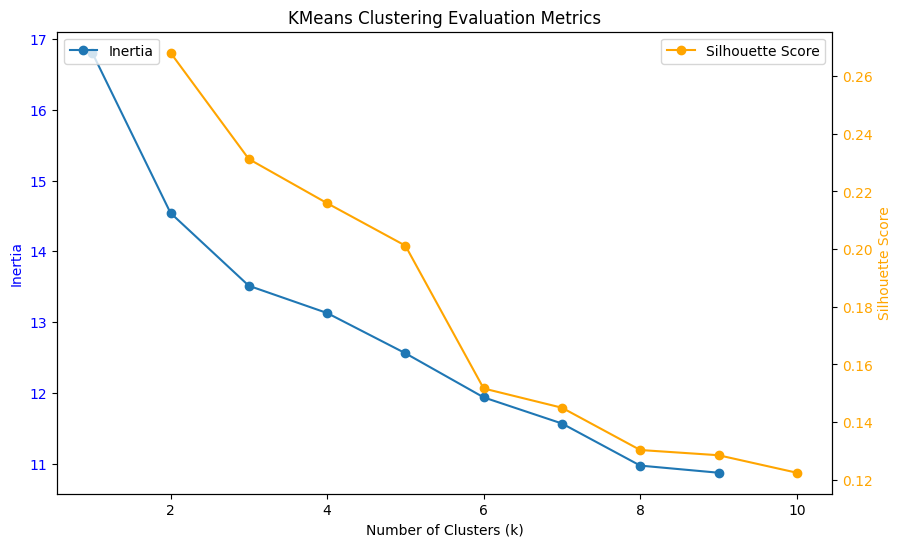

In [189]:
evaluate_kmeans(df_day_norm, metric='euclidean')

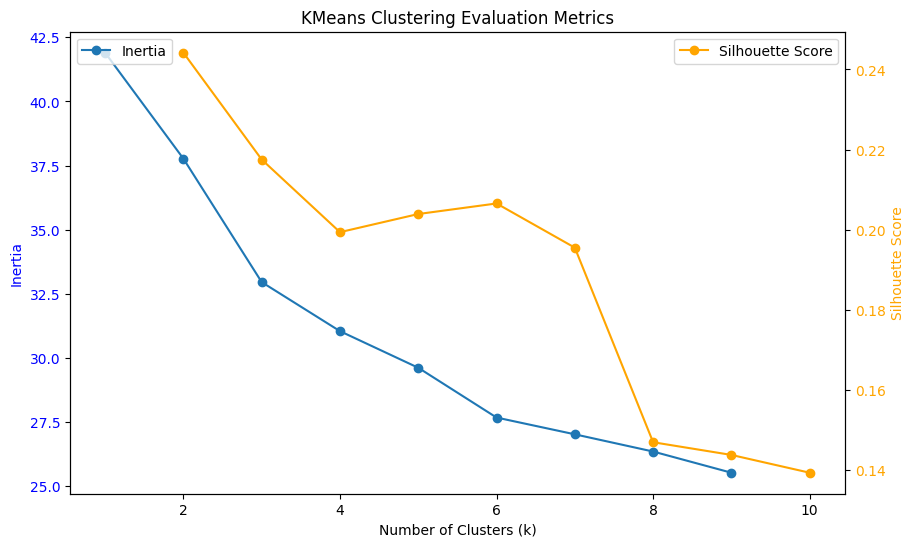

In [190]:
evaluate_kmeans(df_hour_norm, metric='euclidean')

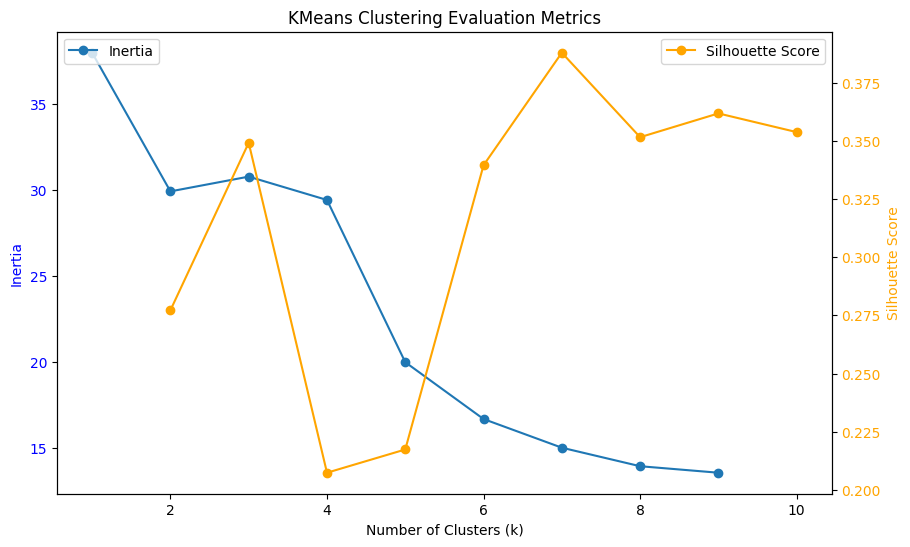

In [191]:
evaluate_kmeans(df_min_norm, metric='euclidean')

Сложно выделить оптимальное количество кластеров, но кажется будет оптимально 6

In [201]:
n_clusters = 6
valid_tickers = df_day_norm.index.tolist() 

km_e_day  = TimeSeriesKMeans(n_clusters=n_clusters, random_state=42, metric='euclidean')
km_e_hour = TimeSeriesKMeans(n_clusters=n_clusters, random_state=42, metric='euclidean')
km_e_min  = TimeSeriesKMeans(n_clusters=n_clusters, random_state=42, metric='euclidean')

labels_day  = km_e_day.fit_predict(df_day_norm)
labels_hour = km_e_hour.fit_predict(df_hour_norm)
labels_min  = km_e_min.fit_predict(df_min_norm)

labels_e = pd.DataFrame({
    "ticker": valid_tickers,
    "cluster_day": labels_day,
    "cluster_hour": labels_hour,
    "cluster_min": labels_min,
})

btc_row = labels_e[labels_e["ticker"] == "BTC"].iloc[0]
btc_c_day, btc_c_hour, btc_c_min = btc_row[["cluster_day", "cluster_hour", "cluster_min"]]

not_with_btc_day  = labels_e[labels_e["cluster_day"]  != btc_c_day]["ticker"].tolist()
not_with_btc_hour = labels_e[labels_e["cluster_hour"] != btc_c_hour]["ticker"].tolist()
not_with_btc_min  = labels_e[labels_e["cluster_min"]  != btc_c_min]["ticker"].tolist()

print("Евклидово, не в кластере BTC (day) :", not_with_btc_day)
print("Евклидово, не в кластере BTC (hour):", not_with_btc_hour)
print("Евклидово, не в кластере BTC (min) :", not_with_btc_min)

Евклидово, не в кластере BTC (day) : ['DOT', 'ADA', 'XLM', 'AAVE', 'UNI', 'HBAR', 'APT', 'BCH', 'FLY', 'UNION', 'YB', 'ADX', 'ANIME', 'SNX', 'FARTCOIN', 'ANT', 'BLESS', 'ENJ', 'FIL', 'WCT', 'YFI', 'SCA', 'SIGMA', 'GMT', 'TEL', 'VELOD', 'MV', 'FORTH', 'ETHW', 'SAUCE', 'OSMO', 'MON', 'MAT', 'COMP', 'KAT', 'ALCH', 'BIO', 'ZAMA', 'PLA', 'BNC', 'OMG', 'SWARMS', 'USDG', 'FIGHT', 'MERL', 'NODE', 'STRK', 'SHAPE', 'MEME', 'GAL', 'RAD', 'SAROS', 'TEA', 'SAND', 'GMX', 'RENDER', 'RAIN', 'TURBO', 'OOB', 'LDO', 'GSTSOL', 'BDX', 'STORJ', 'VOOI', 'XRT', 'M', 'GHIBLI', 'ENA', 'K']
Евклидово, не в кластере BTC (hour): ['CRO', 'DOT', 'XLM', 'XRP', 'NEAR', 'BCH', 'FLY', 'JAILSTOOL', 'UNION', 'YB', 'ADX', 'ANT', 'BLESS', 'ENJ', 'WCT', 'YFI', 'SCA', 'SIGMA', 'TEL', 'VELOD', 'MV', 'FORTH', 'ETHW', 'DEEP', 'DOVU', 'MON', 'MAT', 'KAT', 'ALCH', 'BIO', 'ZAMA', 'PLA', 'BNC', 'SWARMS', 'USDG', 'DEGEN', 'FIGHT', 'MERL', 'NODE', 'SHAPE', 'MEME', 'RHEA', 'GAL', 'RAD', 'SAROS', 'AIO', 'TEA', 'RENDER', 'PUFFER', 'RAIN'

In [202]:
# монеты, которые не в кластере BTC на всех 3 масштабах (евклидово)
stable_diff_dtw = set(not_with_btc_day) & set(not_with_btc_hour) & set(not_with_btc_min)
print("Монеты, стабильно не вместе с BTC (DTW):", stable_diff_dtw)

Монеты, стабильно не вместе с BTC (DTW): {'MV', 'FLY', 'SWARMS', 'MAT', 'ZAMA', 'BIO', 'GSTSOL', 'BCH', 'MEME', 'VOOI', 'XRT', 'TEL', 'K', 'SIGMA', 'ALCH', 'NODE', 'SAROS', 'BLESS', 'BNC', 'KAT', 'ENJ', 'YFI', 'BDX', 'ANT', 'DOT', 'OOB', 'GAL', 'USDG', 'SCA', 'PLA', 'M', 'ADX', 'ETHW', 'VELOD', 'WCT', 'TEA', 'FIGHT', 'MON', 'MERL', 'RAD', 'SHAPE', 'YB'}


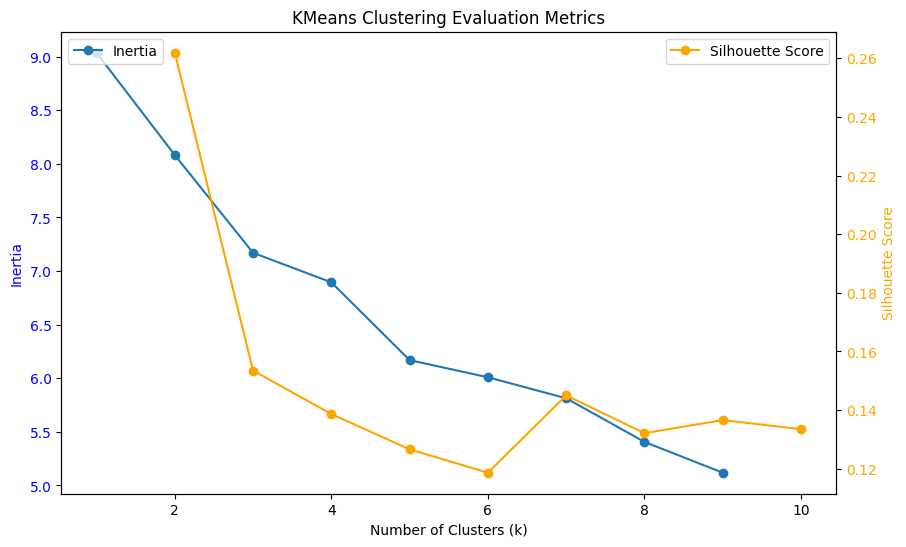

In [196]:
evaluate_kmeans(df_day_norm, metric='dtw')

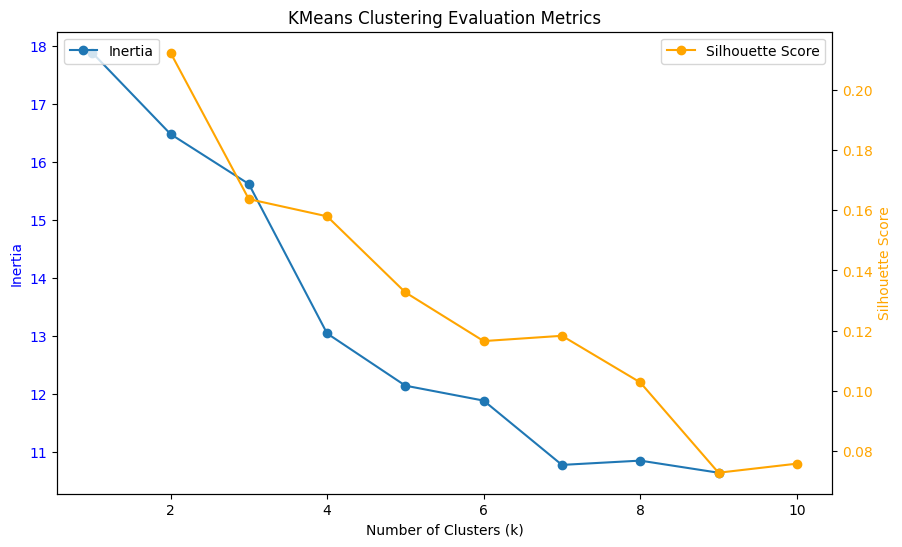

In [197]:
evaluate_kmeans(df_hour_norm, metric='dtw')

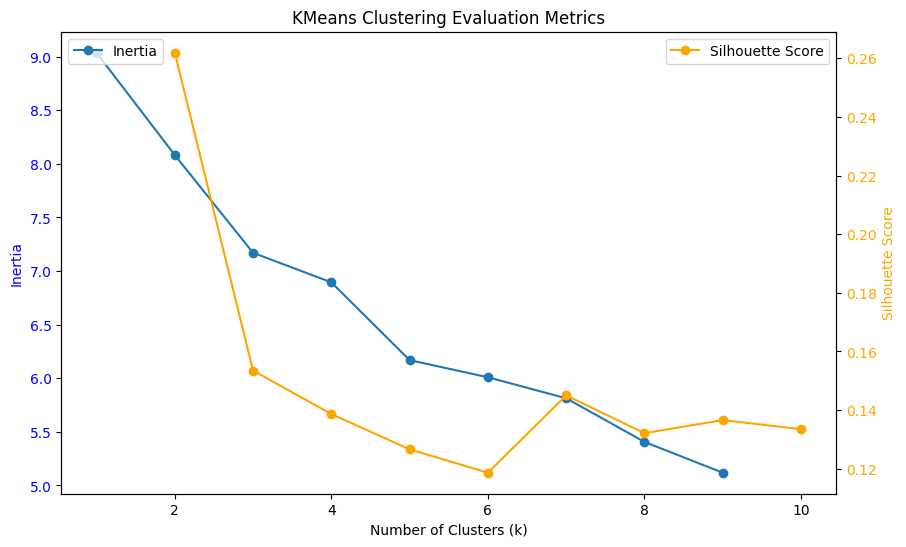

In [198]:
evaluate_kmeans(df_day_norm, metric='dtw')

Тут как-то еще менее очевидно. Остановимся тоже на 6 кластерах

In [199]:
n_clusters = 6
valid_tickers = df_day_norm.index.tolist() 

km_d_day  = TimeSeriesKMeans(n_clusters=n_clusters, random_state=42, metric='euclidean')
km_d_hour = TimeSeriesKMeans(n_clusters=n_clusters, random_state=42, metric='euclidean')
km_d_min  = TimeSeriesKMeans(n_clusters=n_clusters, random_state=42, metric='euclidean')

labels_day  = km_d_day.fit_predict(df_day_norm)
labels_hour = km_d_hour.fit_predict(df_hour_norm)
labels_min  = km_d_min.fit_predict(df_min_norm)

labels_d = pd.DataFrame({
    "ticker": valid_tickers,
    "cluster_day": labels_day,
    "cluster_hour": labels_hour,
    "cluster_min": labels_min,
})

btc_row = labels_d[labels_d["ticker"] == "BTC"].iloc[0]
btc_c_day, btc_c_hour, btc_c_min = btc_row[["cluster_day", "cluster_hour", "cluster_min"]]

not_with_btc_day  = labels_d[labels_d["cluster_day"]  != btc_c_day]["ticker"].tolist()
not_with_btc_hour = labels_d[labels_d["cluster_hour"] != btc_c_hour]["ticker"].tolist()
not_with_btc_min  = labels_d[labels_d["cluster_min"]  != btc_c_min]["ticker"].tolist()

print("Евклидово, не в кластере BTC (day) :", not_with_btc_day)
print("Евклидово, не в кластере BTC (hour):", not_with_btc_hour)
print("Евклидово, не в кластере BTC (min) :", not_with_btc_min)

Евклидово, не в кластере BTC (day) : ['DOT', 'ADA', 'XLM', 'AAVE', 'UNI', 'HBAR', 'APT', 'BCH', 'FLY', 'UNION', 'YB', 'ADX', 'ANIME', 'SNX', 'FARTCOIN', 'ANT', 'BLESS', 'ENJ', 'FIL', 'WCT', 'YFI', 'SCA', 'SIGMA', 'GMT', 'TEL', 'VELOD', 'MV', 'FORTH', 'ETHW', 'SAUCE', 'OSMO', 'MON', 'MAT', 'COMP', 'KAT', 'ALCH', 'BIO', 'ZAMA', 'PLA', 'BNC', 'OMG', 'SWARMS', 'USDG', 'FIGHT', 'MERL', 'NODE', 'STRK', 'SHAPE', 'MEME', 'GAL', 'RAD', 'SAROS', 'TEA', 'SAND', 'GMX', 'RENDER', 'RAIN', 'TURBO', 'OOB', 'LDO', 'GSTSOL', 'BDX', 'STORJ', 'VOOI', 'XRT', 'M', 'GHIBLI', 'ENA', 'K']
Евклидово, не в кластере BTC (hour): ['CRO', 'DOT', 'XLM', 'XRP', 'NEAR', 'BCH', 'FLY', 'JAILSTOOL', 'UNION', 'YB', 'ADX', 'ANT', 'BLESS', 'ENJ', 'WCT', 'YFI', 'SCA', 'SIGMA', 'TEL', 'VELOD', 'MV', 'FORTH', 'ETHW', 'DEEP', 'DOVU', 'MON', 'MAT', 'KAT', 'ALCH', 'BIO', 'ZAMA', 'PLA', 'BNC', 'SWARMS', 'USDG', 'DEGEN', 'FIGHT', 'MERL', 'NODE', 'SHAPE', 'MEME', 'RHEA', 'GAL', 'RAD', 'SAROS', 'AIO', 'TEA', 'RENDER', 'PUFFER', 'RAIN'

In [200]:
# монеты, которые не в кластере BTC на всех 3 масштабах (DTW)
stable_diff_dtw = set(not_with_btc_day) & set(not_with_btc_hour) & set(not_with_btc_min)
print("Монеты, стабильно не вместе с BTC (DTW):", stable_diff_dtw)

Монеты, стабильно не вместе с BTC (DTW): {'MV', 'FLY', 'SWARMS', 'MAT', 'ZAMA', 'BIO', 'GSTSOL', 'BCH', 'MEME', 'VOOI', 'XRT', 'TEL', 'K', 'SIGMA', 'ALCH', 'NODE', 'SAROS', 'BLESS', 'BNC', 'KAT', 'ENJ', 'YFI', 'BDX', 'ANT', 'DOT', 'OOB', 'GAL', 'USDG', 'SCA', 'PLA', 'M', 'ADX', 'ETHW', 'VELOD', 'WCT', 'TEA', 'FIGHT', 'MON', 'MERL', 'RAD', 'SHAPE', 'YB'}
